In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [3]:
df = pd.read_csv("hotel_bookings.csv")

In [5]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [8]:
df.describe(include='all')

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


In [9]:
print(df[['agent', 'company', 'country']].isnull().sum())

df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

agent       16340
company    112593
country       488
dtype: int64


In [10]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

df['arrival_date_month'] = pd.Categorical(
    df['arrival_date_month'],
    categories=month_order,
    ordered=True
)

df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'].astype(str) + '-' +
    df['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d',
    errors='coerce'
)

/tmp/ipykernel_551/4146455772.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(


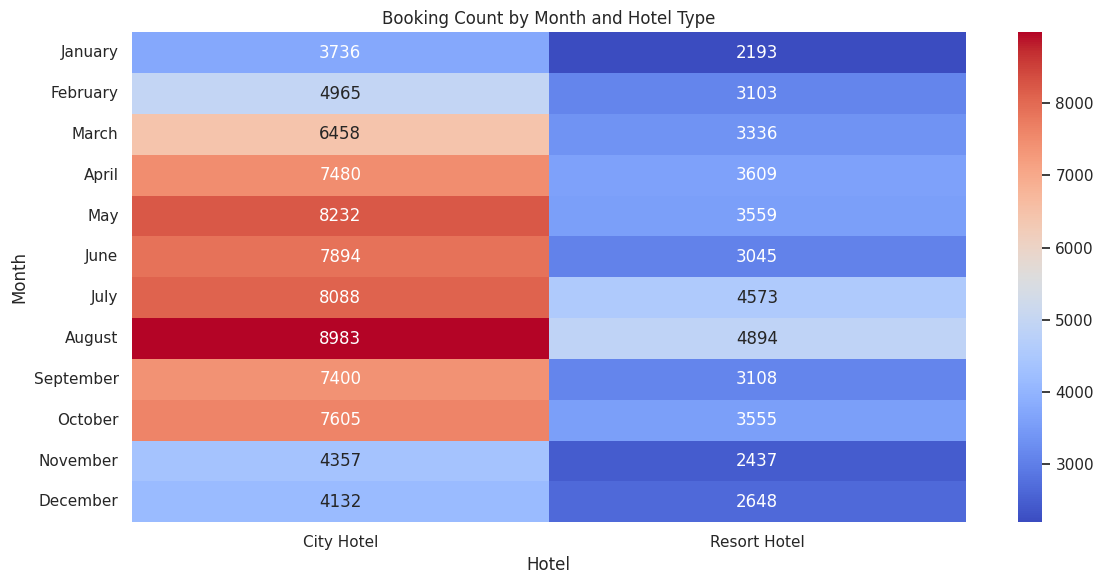

In [21]:
pivot_table = df.pivot_table(
    index='arrival_date_month',
    columns='hotel',
    aggfunc='size'
)

pivot_table = pivot_table.loc[month_order]
plt.figure()
sns.heatmap(pivot_table, annot=True, fmt='g', cmap='coolwarm')
plt.title('Booking Count by Month and Hotel Type')
plt.xlabel('Hotel')
plt.ylabel('Month')
plt.tight_layout()
plt.show()

/tmp/ipykernel_551/1781254502.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_cancel = df.groupby(['arrival_date_month', 'hotel'])['is_canceled'].mean().reset_index()


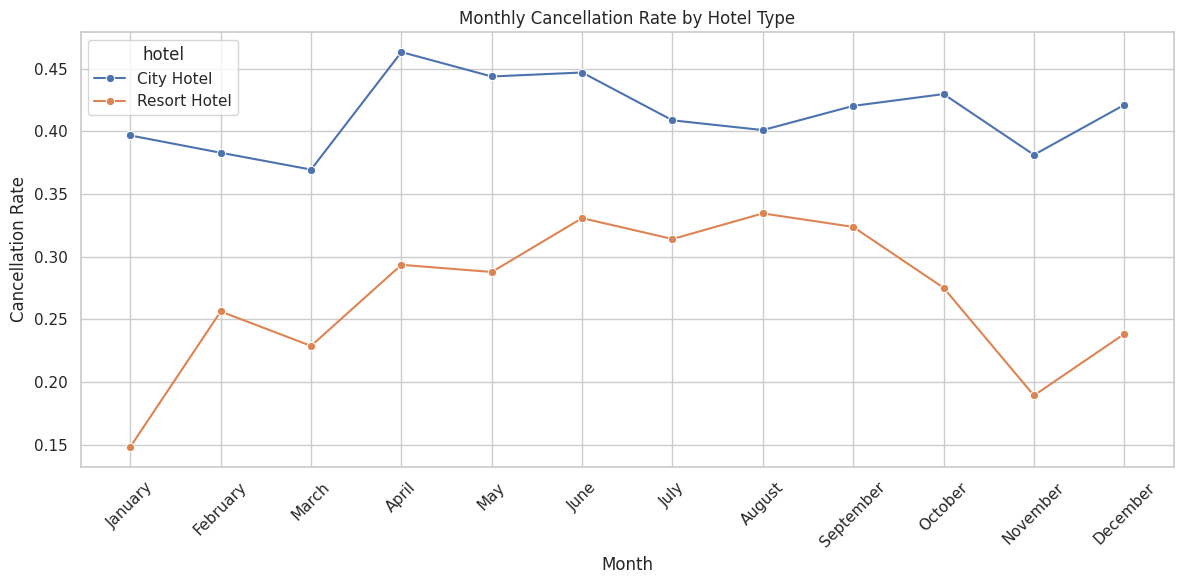

In [22]:
monthly_cancel = df.groupby(['arrival_date_month', 'hotel'])['is_canceled'].mean().reset_index()
monthly_cancel['arrival_date_month'] = pd.Categorical(
    monthly_cancel['arrival_date_month'],
    categories=month_order,
    ordered=True
)

monthly_cancel = monthly_cancel.sort_values('arrival_date_month')
plt.figure()
sns.lineplot(data=monthly_cancel, x='arrival_date_month', y='is_canceled', hue='hotel', marker='o')
plt.title('Monthly Cancellation Rate by Hotel Type')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
lead_time_analysis = df.groupby('is_canceled')['lead_time'].mean().reset_index()
print(lead_time_analysis)

   is_canceled   lead_time
0            0   79.984687
1            1  144.848815


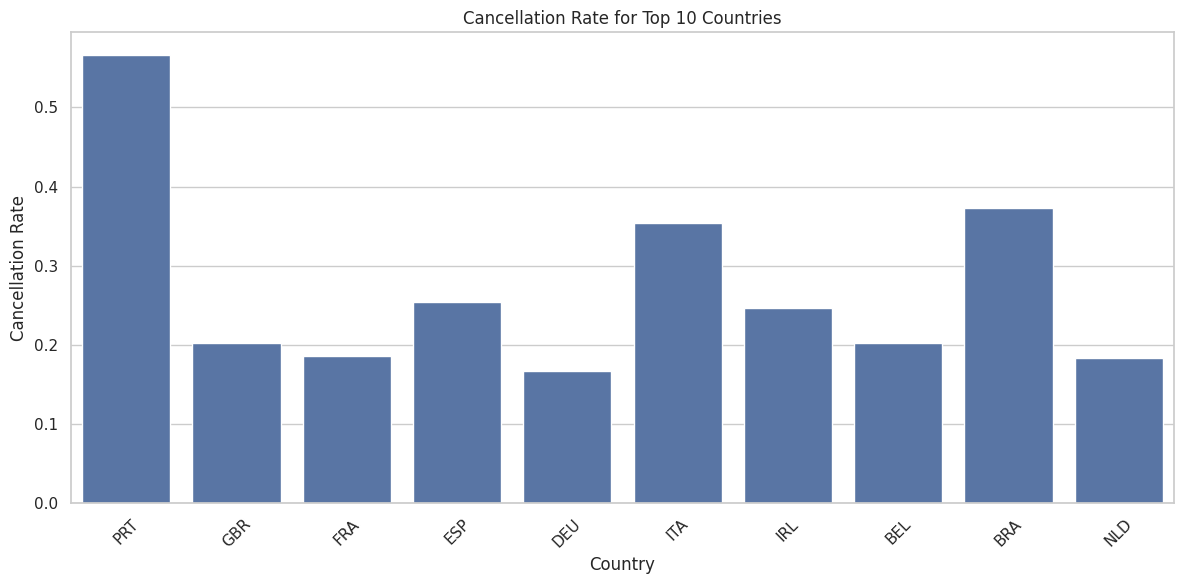

In [24]:
top_countries_counts = df['country'].value_counts().head(10)

country_df = df[df['country'].isin(top_countries_counts.index)]

country_cancel = country_df.groupby('country')['is_canceled'].mean()
country_cancel = country_cancel.loc[top_countries_counts.index]
plt.figure()
sns.barplot(x=top_countries_counts.index, y=country_cancel.values)
plt.title('Cancellation Rate for Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Cancellation Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

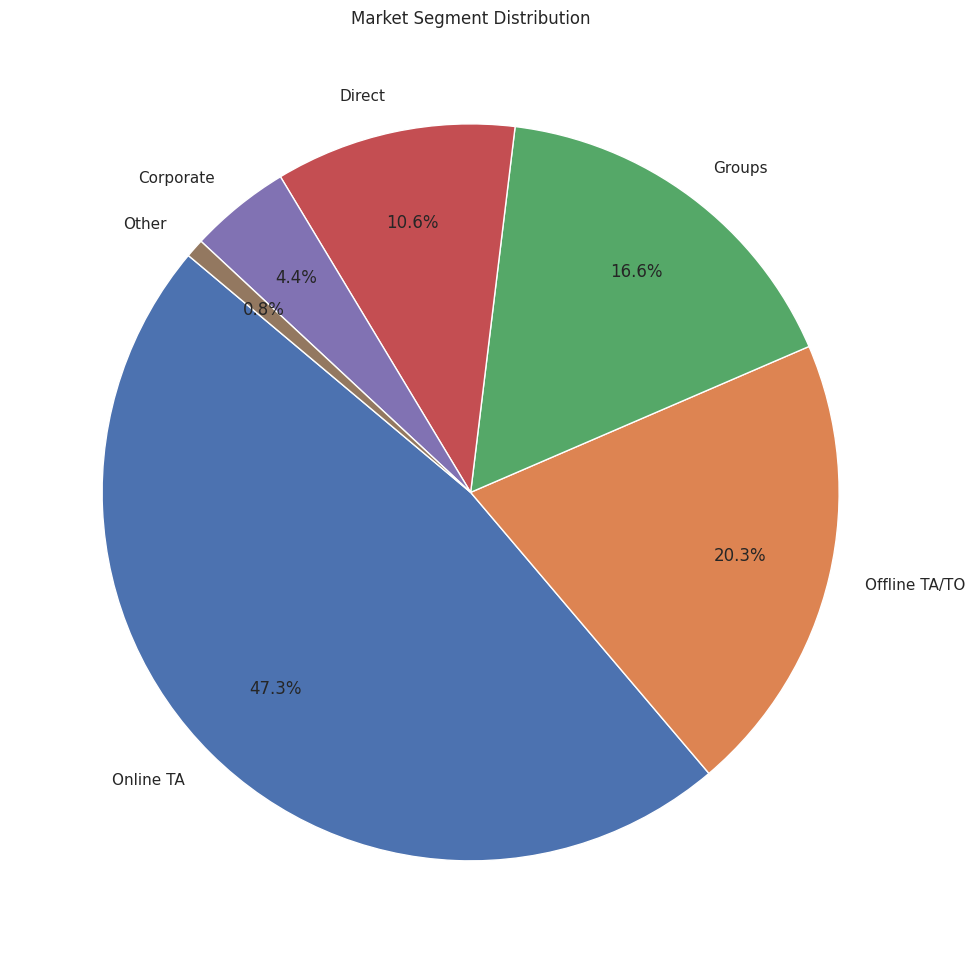

In [40]:
segment_counts = df['market_segment'].value_counts()

threshold = 0.02
small_segments = segment_counts[segment_counts / segment_counts.sum() < threshold]
big_segments = segment_counts[segment_counts / segment_counts.sum() >= threshold]

segment_counts_clean = big_segments.copy()
segment_counts_clean['Other'] = small_segments.sum()

plt.figure(figsize=(10, 10))

plt.pie(
    segment_counts_clean,
    labels=segment_counts_clean.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75
)
plt.title('Market Segment Distribution')
plt.tight_layout()
plt.show()

/tmp/ipykernel_551/1579310308.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adr_analysis = df.groupby(['arrival_date_month', 'hotel'])['adr'].mean().reset_index()
/tmp/ipykernel_551/1579310308.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_demand = df.groupby('arrival_date_month').size().reindex(month_order)


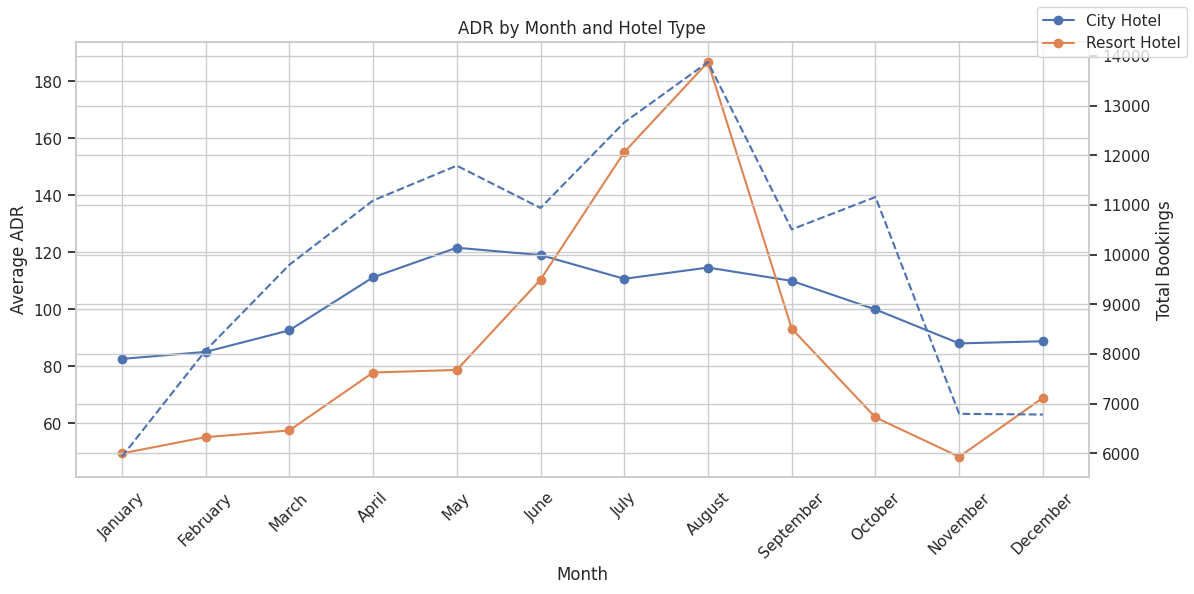

In [41]:
adr_analysis = df.groupby(['arrival_date_month', 'hotel'])['adr'].mean().reset_index()
adr_analysis['arrival_date_month'] = pd.Categorical(
    adr_analysis['arrival_date_month'],
    categories=month_order,
    ordered=True
)

adr_analysis = adr_analysis.sort_values('arrival_date_month')

fig, ax1 = plt.subplots()

for hotel_type in adr_analysis['hotel'].unique():
    subset = adr_analysis[adr_analysis['hotel'] == hotel_type]
    ax1.plot(subset['arrival_date_month'], subset['adr'], marker='o', label=hotel_type)

ax1.set_xlabel('Month')
ax1.set_ylabel('Average ADR')
ax1.set_title('ADR by Month and Hotel Type')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
monthly_demand = df.groupby('arrival_date_month').size().reindex(month_order)
ax2.plot(month_order, monthly_demand, linestyle='--')
ax2.set_ylabel('Total Bookings')

fig.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [42]:
best_segment = segment_summary['cancellation_rate'].idxmin()
print("Best Market Segment (Lowest Cancellation Rate):", best_segment)

Best Market Segment (Lowest Cancellation Rate): Complementary
